# CG projector ranks for the system_303 problem

This focused copy of the non-simplified v3 notebook retains only the data preparation, fixed-iteration CG directions, numerical-rank calculation, and requested rank plot. The numerical-rank tolerance and A-normalization match v3.

For the large projector expressions, the notebook uses the exact identities

$$
Q_m=P_mG_m^{-1}P_m^T\widehat A,\qquad
\operatorname{rank}(Q_m)=\operatorname{rank}(P_m),\qquad
\operatorname{rank}(\Pi_m)=n-\operatorname{rank}(Q_m),
$$

on the numerically independent column space. This avoids forming a dense projector at every iteration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import get_lapack_funcs

data_dir = Path("system_303")
A_full = np.genfromtxt(data_dir / "stiffness_beam_A.dat", delimiter=",")
b_full = np.genfromtxt(data_dir / "forcing_b.dat")
box = np.genfromtxt(data_dir / "B0_wide_bc.dat", delimiter=",")

# Match the 300 free coordinates used by the non-simplified v3 notebook.
A = A_full[3:, 3:]
b = b_full[3:]
lower = box[3:, 0]
upper = box[3:, 1]
n = b.size

diagonal = np.diag(A)
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
A_hat = A / scale[:, None] / scale[None, :]
b_hat = b / scale
x0 = scale * (0.5 * (lower + upper))

max_cg_iterations = 500
rank_tolerance = 1e-10
print(f"system dimension n: {n}")
print(f"maximum CG iteration count: {max_cg_iterations}")

system dimension n: 300
maximum CG iteration count: 500


In [2]:
def fixed_cg_directions(A, b, x0, iterations):
    """Run exactly `iterations` CG steps and retain A-normalized p_k."""
    x = np.array(x0, dtype=float, copy=True)
    residual = b - A @ x
    direction = residual.copy()
    # Fortran order lets LAPACK factor this array in place without a large copy.
    directions = np.empty((b.size, iterations), dtype=float, order="F")

    for k in range(iterations):
        applied_direction = A @ direction
        residual_norm_sq = float(residual @ residual)
        denominator = float(direction @ applied_direction)
        if denominator <= 0.0 or not np.isfinite(denominator):
            raise RuntimeError(f"CG breakdown at iteration {k + 1}.")

        a_norm_sq = float(direction @ applied_direction)
        if a_norm_sq <= 0.0 or not np.isfinite(a_norm_sq):
            raise RuntimeError(f"Invalid A-norm at iteration {k + 1}.")
        directions[:, k] = direction / np.sqrt(a_norm_sq)
        alpha = residual_norm_sq / denominator
        x += alpha * direction
        next_residual = residual - alpha * applied_direction
        if k + 1 < iterations:
            beta = float(next_residual @ next_residual) / residual_norm_sq
            direction = next_residual + beta * direction
        residual = next_residual

    return directions


def prefix_rank_profile(normalized_directions, tolerance=1e-10):
    """Return a rank-revealing profile for every leading CG prefix P_m.

    CG directions are first A-normalized, as in the v3 projection selector.
    One pivoted QR of the full trajectory determines the independent numerical
    column basis. Counting those basis columns by original CG index gives the
    numerical rank profile at every m without repeatedly factoring P[:, :m].
    """
    # geqp3 computes pivoted QR without explicitly forming the large Q factor.
    normalized_f = np.asfortranarray(normalized_directions)
    geqp3 = get_lapack_funcs("geqp3", (normalized_f,))
    factored, pivots, tau, work, info = geqp3(
        normalized_f, overwrite_a=True
    )
    if info != 0:
        raise RuntimeError(f"LAPACK geqp3 failed with info={info}.")

    diagonal = np.abs(np.diag(factored[: min(factored.shape), :]))
    if diagonal.size == 0 or diagonal[0] == 0.0:
        numerical_rank = 0
        independent_indices = np.array([], dtype=int)
    else:
        numerical_rank = int(np.sum(diagonal > tolerance * diagonal[0]))
        independent_indices = np.asarray(pivots[:numerical_rank] - 1, dtype=int)

    increments = np.bincount(
        independent_indices, minlength=normalized_directions.shape[1]
    )
    rank_P = np.r_[0, np.cumsum(increments, dtype=int)]
    return rank_P, numerical_rank


def projector_rank_histories(rank_P, n):
    """Use Q=P G^-1 P^T A and Pi=I-Q rank identities.

    On the numerical independent column space, G is nonsingular, A is SPD,
    rank(Q_m)=rank(P_m), and rank(Pi_m)=n-rank(Q_m).
    """
    rank_Q = rank_P.copy()
    rank_Pi = n - rank_Q
    return rank_Q, rank_Pi


def plot_rank_history(ax, iterations, rank_P, rank_Q, rank_Pi, n, title):
    expected_P = iterations
    expected_Pi = n - rank_Q
    marker_stride = max(1, len(iterations) // 28)

    # P_m and Q_m use the left axis.
    ax.plot(
        iterations, expected_P, color="0.55", linestyle="--", linewidth=1.8,
        label=r"Expected rank$(P_m)=m$", zorder=1,
    )
    ax.plot(
        iterations, rank_Q, color="tab:orange", linestyle="-.", linewidth=1.7,
        marker="x", markevery=marker_stride, markersize=4,
        label=r"Actual rank$(Q_m)$", zorder=2,
    )
    ax.plot(
        iterations, rank_P, color="tab:blue", linewidth=1.4,
        marker="o", markevery=marker_stride, markersize=3, fillstyle="none",
        label=r"Actual rank$(P_m)$", zorder=3,
    )
    ax.set_xlabel("CG iteration $m$")
    ax.set_ylabel(r"rank$(P_m)$ and rank$(Q_m)$")
    ax.grid(alpha=0.25)

    # Pi_m is on a second scale, which is essential for the 21,570-D system.
    # pi_ax = ax.twinx()
    ax.plot(
        iterations, expected_Pi, color="0.35", linestyle=":", linewidth=2.2,
        label=r"Expected rank$(\Pi_m)=n-$rank$(Q_m)$", zorder=1,
    )
    ax.plot(
        iterations, rank_Pi, color="tab:green", linewidth=1.5,
        marker="s", markevery=marker_stride, markersize=3, fillstyle="none",
        label=r"Actual rank$(\Pi_m)$", zorder=2,
    )
    ax.set_ylabel(r"rank$(\Pi_m)$")

    lines = ax.get_lines() 
    ax.legend(lines, [line.get_label() for line in lines], loc="best", fontsize=8)
    ax.set_title(title)
    return ax


In [3]:
directions = fixed_cg_directions(
    A_hat, b_hat, x0, max_cg_iterations
)
rank_P, final_rank = prefix_rank_profile(
    directions, tolerance=rank_tolerance
)
rank_Q, rank_Pi = projector_rank_histories(rank_P, n)
iterations = np.arange(max_cg_iterations + 1)

print(f"final numerical rank(P_m): {final_rank}")
print(f"final rank(Q_m): {rank_Q[-1]}")
print(f"final rank(Pi_m): {rank_Pi[-1]}")

final numerical rank(P_m): 200
final rank(Q_m): 200
final rank(Pi_m): 100


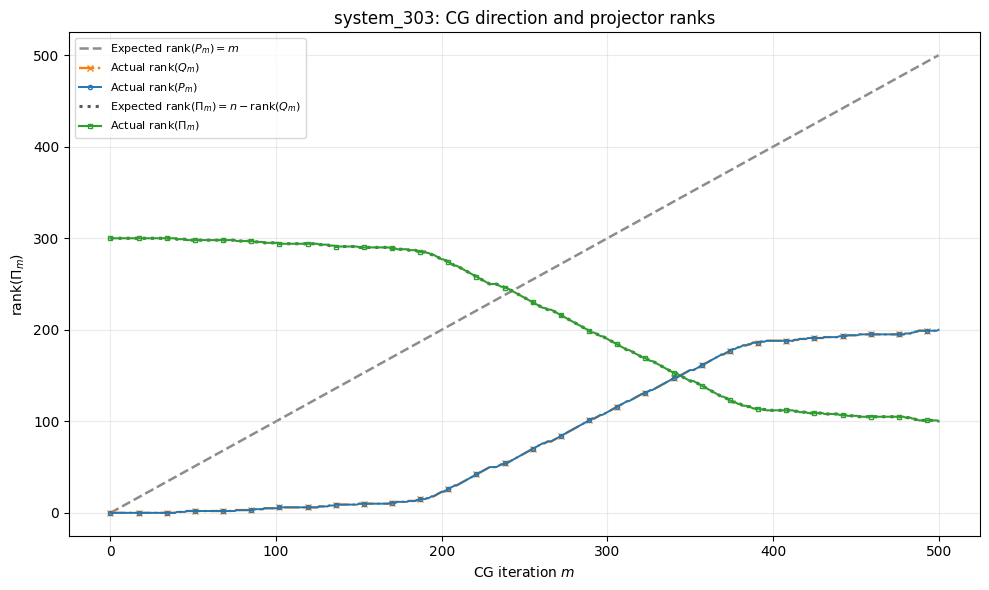

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_rank_history(
    ax, iterations, rank_P, rank_Q, rank_Pi, n,
    "system_303: CG direction and projector ranks",
)
fig.tight_layout()
plt.show()